In [1]:
# ============================================================
# 09 | Inference — Test Models on New Images
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from torchvision import transforms

# ── Paths ────────────────────────────────────────────────────
MODELS_DIR = Path("../models")

# ── Constants ────────────────────────────────────────────────
CLASS_NAMES = ["Glass", "Metal", "Organic", "Paper", "Plastic"]
IMAGE_SIZE  = 224
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Transforms ───────────────────────────────────────────────
inference_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print(f"✅ Setup done | Device: {DEVICE}")

C:\Users\seif almaz\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Setup done | Device: cuda


In [3]:
# ============================================================
# Cell 2 (fixed) | Load Models
# ============================================================
from torchvision import models

def load_resnet50(device):
    model = timm.create_model("resnet50", pretrained=False, num_classes=5)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 5)
    )
    checkpoint = torch.load(MODELS_DIR / "resnet50_finetuned_best.pth", map_location=device)
    state_dict = checkpoint.get("model_state_dict", checkpoint)
    model.load_state_dict(state_dict)
    model.to(device).eval()
    print("✅ ResNet50 loaded")
    return model

def load_efficientnet(device):
    # saved with torchvision, not timm
    model = models.efficientnet_b3(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 5)
    )
    checkpoint = torch.load(MODELS_DIR / "efficientnet_b3_finetuned_best.pth", map_location=device)
    state_dict = checkpoint.get("model_state_dict", checkpoint)
    model.load_state_dict(state_dict)
    model.to(device).eval()
    print("✅ EfficientNetB3 loaded")
    return model

# ── Choose your model here ───────────────────────────────────
MODEL_CHOICE = 2   # 1 = ResNet50, 2 = EfficientNetB3

resnet_model = None
effnet_model = None

if MODEL_CHOICE == 1:
    resnet_model = load_resnet50(DEVICE)
    ACTIVE_MODEL = resnet_model
    MODEL_NAME   = "ResNet50"
elif MODEL_CHOICE == 2:
    effnet_model = load_efficientnet(DEVICE)
    ACTIVE_MODEL = effnet_model
    MODEL_NAME   = "EfficientNetB3"

print(f"\n✅ Active model: {MODEL_NAME}")

✅ EfficientNetB3 loaded

✅ Active model: EfficientNetB3


In [4]:
# ============================================================
# Cell 3 | Inference Functions
# ============================================================

def predict_single(image_path, model, device):
    """Run inference on a single image. Returns predicted class, confidence, and top-3."""
    img = Image.open(image_path).convert("RGB")
    tensor = inference_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        probs  = F.softmax(logits, dim=1).squeeze()

    top3_probs, top3_idxs = torch.topk(probs, 3)
    top3 = [(CLASS_NAMES[i], round(p.item() * 100, 2)) for i, p in zip(top3_idxs, top3_probs)]

    pred_class = top3[0][0]
    confidence = top3[0][1]

    return pred_class, confidence, top3, img


def predict_folder(folder_path, model, device):
    """Run inference on all images in a folder. Returns a list of result dicts."""
    folder = Path(folder_path)
    extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    image_paths = [p for p in folder.iterdir() if p.suffix.lower() in extensions]

    if not image_paths:
        print(f"⚠️  No images found in {folder}")
        return []

    results = []
    for path in image_paths:
        try:
            pred_class, confidence, top3, _ = predict_single(path, model, device)
            results.append({
                "file":       path.name,
                "prediction": pred_class,
                "confidence": confidence,
                "top3":       top3,
            })
        except Exception as e:
            print(f"  ⚠️  Skipped {path.name}: {e}")

    return results


print("✅ Inference functions ready")

✅ Inference functions ready


In [5]:
# ============================================================
# Cell 4 | Visualization Function
# ============================================================

def visualize_prediction(image_path, model, device, model_name="Model"):
    """Display image alongside top-3 predictions as a horizontal bar chart."""
    pred_class, confidence, top3, img = predict_single(image_path, model, device)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # ── Left: image ──────────────────────────────────────────
    axes[0].imshow(img)
    axes[0].axis("off")

    # border color: green if high confidence, orange if uncertain
    border_color = "#2ecc71" if confidence >= 70 else "#e67e22"
    for spine in axes[0].spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)

    axes[0].set_title(
        f"Predicted: {pred_class}\nConfidence: {confidence:.1f}%",
        fontsize=12, fontweight="bold", color=border_color, pad=10
    )

    # ── Right: top-3 bar chart ───────────────────────────────
    labels = [f"{cls}" for cls, _ in top3]
    values = [prob for _, prob in top3]
    colors = ["#2ecc71" if labels[i] == pred_class else "#95a5a6" for i in range(len(labels))]

    bars = axes[1].barh(labels[::-1], values[::-1], color=colors[::-1],
                        edgecolor="white", height=0.5)

    for bar, val in zip(bars, values[::-1]):
        axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f"{val:.1f}%", va="center", fontsize=11, fontweight="bold")

    axes[1].set_xlim(0, 115)
    axes[1].set_xlabel("Confidence (%)", fontsize=10)
    axes[1].set_title(f"Top-3 Predictions — {model_name}", fontsize=11, fontweight="bold")
    axes[1].grid(axis="x", alpha=0.3, linestyle="--")
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)

    plt.suptitle(Path(image_path).name, fontsize=10, color="gray", y=1.01)
    plt.tight_layout()
    plt.show()
    print(f"  🗂  File      : {Path(image_path).name}")
    print(f"  🏆 Predicted  : {pred_class}")
    print(f"  📊 Confidence : {confidence:.1f}%")
    print(f"  🔢 Top-3      : {top3}")


print("✅ Visualization function ready")

✅ Visualization function ready



✅ Processed 4 images

File                           Prediction      Confidence
──────────────────────────────────────────────────────────
  test.jpg                     Metal               83.7%
  test2.jpg                    Paper               97.7%
  test3.jpg                    Plastic            100.0%
  test4.jpg                    Glass               99.7%


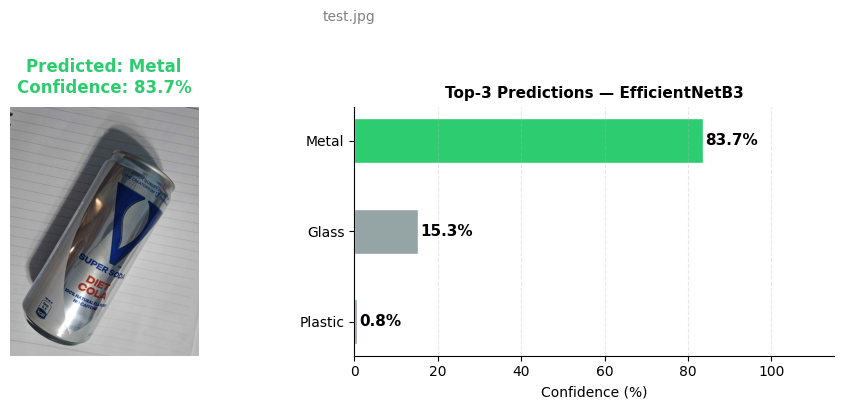

  🗂  File      : test.jpg
  🏆 Predicted  : Metal
  📊 Confidence : 83.7%
  🔢 Top-3      : [('Metal', 83.71), ('Glass', 15.32), ('Plastic', 0.76)]


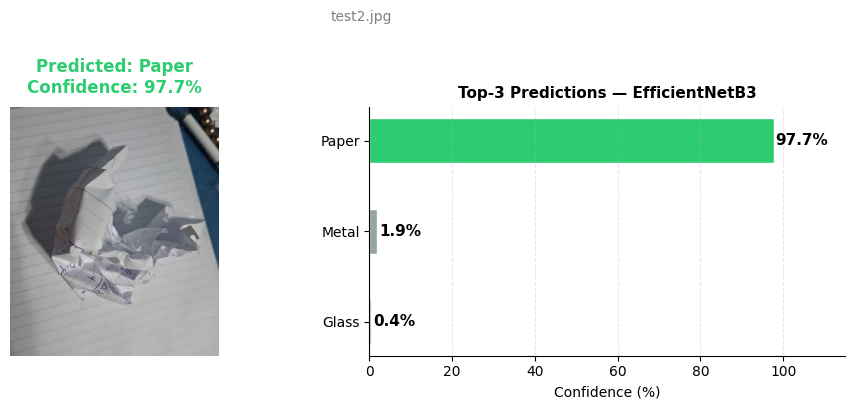

  🗂  File      : test2.jpg
  🏆 Predicted  : Paper
  📊 Confidence : 97.7%
  🔢 Top-3      : [('Paper', 97.67), ('Metal', 1.86), ('Glass', 0.41)]


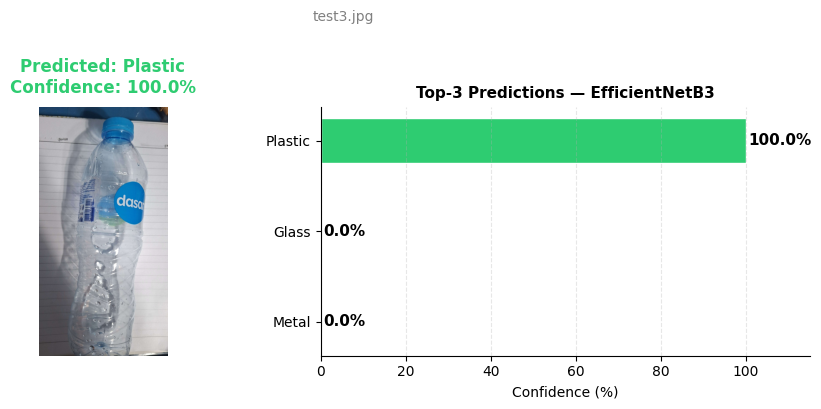

  🗂  File      : test3.jpg
  🏆 Predicted  : Plastic
  📊 Confidence : 100.0%
  🔢 Top-3      : [('Plastic', 100.0), ('Glass', 0.0), ('Metal', 0.0)]


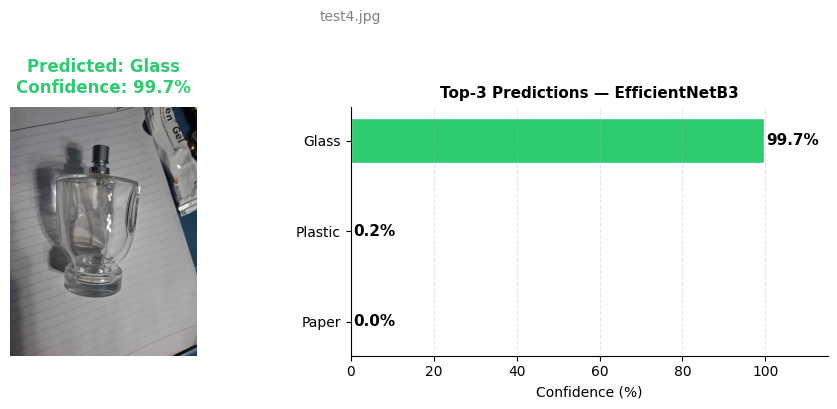

  🗂  File      : test4.jpg
  🏆 Predicted  : Glass
  📊 Confidence : 99.7%
  🔢 Top-3      : [('Glass', 99.73), ('Plastic', 0.2), ('Paper', 0.04)]


In [10]:
# ============================================================
# Cell 5 | Run Inference — Single Image or Folder
# ============================================================

# ── Option A: Single image ───────────────────────────────────
# Set to your image path, e.g. r"C:\Users\seif almaz\Desktop\test.jpg"
SINGLE_IMAGE_PATH = r"F:\Downloads\test2.jpg"

# ── Option B: Folder of images ───────────────────────────────
FOLDER_PATH = r"F:\Downloads\test_neural"

# ── Choose mode: "single" or "folder" ────────────────────────
MODE = "folder"

# ═════════════════════════════════════════════════════════════

if MODE == "single":
    if not Path(SINGLE_IMAGE_PATH).exists():
        print(f"❌ File not found: {SINGLE_IMAGE_PATH}")
    else:
        visualize_prediction(SINGLE_IMAGE_PATH, ACTIVE_MODEL, DEVICE, MODEL_NAME)

elif MODE == "folder":
    if not Path(FOLDER_PATH).exists():
        print(f"❌ Folder not found: {FOLDER_PATH}")
    else:
        results = predict_folder(FOLDER_PATH, ACTIVE_MODEL, DEVICE)

        print(f"\n✅ Processed {len(results)} images\n")
        print(f"{'File':<30} {'Prediction':<15} {'Confidence':>10}")
        print("─" * 58)
        for r in results:
            print(f"  {r['file']:<28} {r['prediction']:<15} {r['confidence']:>8.1f}%")

        # ── Visualize first 6 results ─────────────────────────
        folder = Path(FOLDER_PATH)
        extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        image_paths = [p for p in folder.iterdir() if p.suffix.lower() in extensions][:6]

        for path in image_paths:
            visualize_prediction(path, ACTIVE_MODEL, DEVICE, MODEL_NAME)